# Student Performance Data Analysis
Name: Mukund Rajpurohit  
Internship: Data Analysis with Python —
Maincraft Technology  
Task: Task 1  
Date: 24 May 2026

 ## Importing Libraries
In this step I import all the necessary
libraries needed for data analysis and visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Loading the Dataset
I used pandas to load the student-mat.csv file. The dataset uses
semicolons as separators, so sep=';' was specified.
The dataset contains 395 rows and 33 columns.

In [3]:
#Loading Dataset:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


## Step 2: Exploring and Cleaning Data
In this step I will check for missing values,
remove duplicates and fix data types.

In [4]:
#Explore and Cleaning dataset:
# KEY FIX: sep=';' because file uses semicolons not commas
df = pd.read_csv('student-mat.csv', sep=';')
print("Shape:", df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
#fixing the grade columns:
# G1 and G2 have quotes around numbers — this cleans them
df['G1'] = pd.to_numeric(df['G1'], errors='coerce')
df['G2'] = pd.to_numeric(df['G2'], errors='coerce')

print("Grades cleaned successfully!")
print(df[['G1','G2','G3']].head())

Grades cleaned successfully!
   G1  G2  G3
0   5   6   6
1   5   5   6
2   7   8  10
3  15  14  15
4   6  10  10


## Step 3: Analysis Questions
In this step I analysed the dataset by answering
4 key questions about student performance.

In [6]:
#Analysing questions:
# Q1 - Average of  final grades
avg_grade = df['G3'].mean()
print("Average Final Grade (G3):", round(avg_grade, 2))



Average Final Grade (G3): 10.42


The average final grade was 10.42 out of 20, suggesting
moderate overall student performance.

In [7]:
# Q2 - Students scoring above 15
above_15 = df[df['G3'] > 15]
print("Students above 15:", len(above_15))


Students above 15: 40


40 students scored above 15 out of 395 total, representing
approximately 10% of the class.

In [8]:
# Q3 - Study time correlation
corr = df['studytime'].corr(df['G3'])
print("Correlation:", round(corr, 2))


Correlation: 0.1


The correlation between study time and grades is 0.10,
indicating a very weak positive relationship. This suggests
that study time alone has minimal impact on final grades
and other factors may play a bigger role in performance.

In [9]:
# Q4 - Gender performance
print(df.groupby('sex')['G3'].mean())


sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


Male students performed better on average with a grade of 10.91
out of 20, compared to female students who averaged 9.97 out of 20.
This suggests a slight performance gap between genders, though
both groups show moderate overall academic performance.

## Step 4: Visualizations
 In this step I created 3 charts to visually  represent the data.

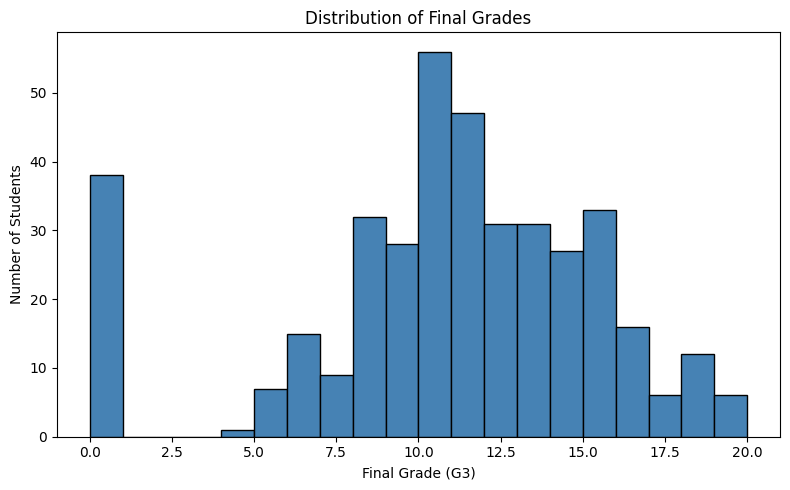

In [10]:
#Chart 1 — Histogram:
plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Grades')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

This histogram shows the distribution of final grades
among 395 students. The majority of students scored
around 10-11 out of 20, indicating moderate academic
performance. There is also a notable spike at 0, which
represents students who may have been absent or did
not appear for the exam.

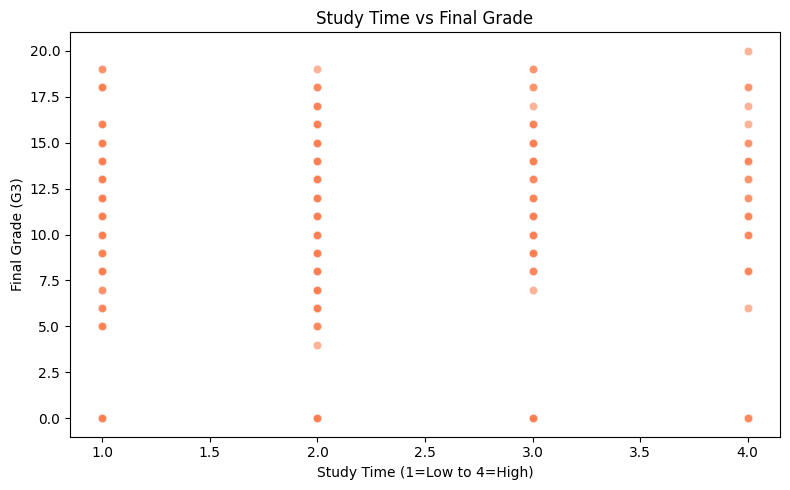

In [11]:
 #Chart 2 — Scatterplot:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='studytime', y='G3', alpha=0.6, color='coral')
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time (1=Low to 4=High)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

The scatterplot shows grades are spread across all study
time levels from 1 to 4. Students with higher study time
do not show a dramatically higher grade, which confirms
our earlier finding of a very weak correlation of 0.10.
This suggests that factors beyond study time such as
attendance, family background or prior knowledge likely
influence final grades more significantly.

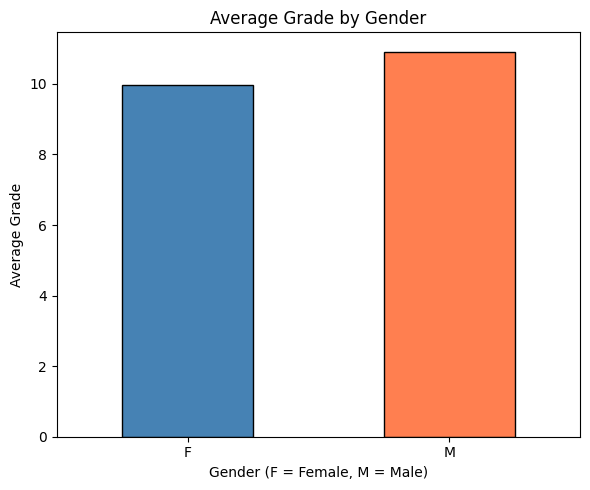

In [12]:
#Chart 3 — Bar Chart:
plt.figure(figsize=(6,5))
df.groupby('sex')['G3'].mean().plot(
    kind='bar',
    color=['steelblue','coral'],
    edgecolor='black')
plt.title('Average Grade by Gender')
plt.xlabel('Gender (F = Female, M = Male)')
plt.ylabel('Average Grade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar chart clearly shows that male students averaged
10.91 compared to female students at 9.97 out of 20.
While male students performed slightly better, the
difference of 0.94 points is relatively small. This
suggests that gender alone is not a significant
determining factor in student academic performance.

## Conclusion
This analysis of the Student Performance dataset revealed the following key findings:

1. The average final grade (G3) was 10.42 out of 20,indicating moderate overall academic performance among students.

2.  40 out of 395 students scored above  15,representing approximately 10% of the class as high performers.

3. Study time showed a very weak positive correlation of 0.10 with final grades. The scatterplot confirmed  that grades are spread across all study time levels, suggesting other factors like attendance, family background and prior knowledge play a bigger role.

4. In this dataset, male students performed slightly better with an average of 10.91 compared to female students at 9.97 out of 20. However the difference of 0.94 points is minimal, indicating gender is not a major factor in performance.

5. A very crucial  observation was the spike of 38 students scoring 0, likely representing students who were absent or did not appear for the final exam.

Overall this task demonstrated the complete data science
workflow of loading, cleaning, analysing and visualizing
a real world dataset using Python. Through this task I
personally learned how visualizations can reveal patterns
that raw numbers alone cannot show.